# MTO/JIT Scheduling Demo — CP-SAT, Batch Splitting, Rescheduling, and OTIF KPIs

This notebook demonstrates the updated business logic:

1. orders have quantities;
2. each order is split into production batches/lots;
3. batches of the same order can move through the routing independently;
4. all MVP orders are MTO and JIT;
5. the optimizer prioritizes MTO OTIF and then partial quantity completed by the promised date;
6. downtime triggers event-driven rescheduling.

Run `factory_scheduling_data_generator.ipynb` first to create `generated_factory_demo_data/synthetic_demo`.


In [1]:
!pip install ortools


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from cp_sat_scheduler import (
    load_data_bundle,
    solve_schedule,
    run_reschedule_on_event,
    compute_kpis,
    validate_schedule,
)

BUNDLE_DIR = Path("generated_factory_demo_data/synthetic_demo")
OUTPUT_DIR = Path("scheduler_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


def show_table(obj, max_rows=None):
    """Print pandas objects as plain text to avoid pandas/Jupyter HTML repr issues."""
    if isinstance(obj, pd.Series):
        obj = obj.to_frame()
    if isinstance(obj, pd.DataFrame) and max_rows is not None:
        obj = obj.head(max_rows)
    print(obj.to_string())


def require_solution(result, label="solve"):
    """Stop early with a clear message if CP-SAT did not return a schedule."""
    if result.status not in {"OPTIMAL", "FEASIBLE"}:
        raise RuntimeError(
            f"{label} did not find a feasible schedule. "
            f"status={result.status}, solve_time={result.solve_time_seconds:.3f}s. "
            "Try increasing time_limit_seconds or reducing num_orders in the generator."
        )


## 1. Load the generated MTO/JIT dataset


In [3]:
bundle = load_data_bundle(BUNDLE_DIR)

print("orders:", bundle.orders.shape)
print("operations:", bundle.operations.shape)
print("machines:", bundle.machines.shape)
print("shifts:", bundle.shifts.shape)
print("total order quantity:", int(bundle.orders["order_quantity"].sum()))
print("number of batches:", bundle.operations[["order_id", "batch_id"]].drop_duplicates().shape[0])

show_table(
    bundle.orders[[
        "order_id",
        "product_family",
        "order_type",
        "order_quantity",
        "num_batches",
        "priority_label",
        "release_time",
        "promised_date",
    ]],
    max_rows=5,
)

print("\nOperation / batch preview:")
show_table(
    bundle.operations[[
        "operation_id",
        "order_id",
        "batch_id",
        "batch_quantity",
        "sequence_index",
        "machine_group_required",
        "total_duration_minutes",
    ]],
    max_rows=10,
)


orders: (20, 12)
operations: (212, 17)
machines: (8, 6)
shifts: (40, 4)
total order quantity: 241
number of batches: 55
  order_id product_family order_type  order_quantity  num_batches priority_label        release_time       promised_date
0  ORD_001        FRAME_A        MTO              12            3         normal 2026-04-20 08:05:00 2026-04-21 22:50:00
1  ORD_002        FRAME_A        MTO              15            3           high 2026-04-20 08:05:00 2026-04-22 16:19:00
2  ORD_003        FRAME_A        MTO              12            3            low 2026-04-20 09:00:00 2026-04-22 05:58:00
3  ORD_004        FRAME_B        MTO              20            4            low 2026-04-20 08:20:00 2026-04-22 21:42:00
4  ORD_005          KIT_C        MTO               8            2         normal 2026-04-20 08:50:00 2026-04-22 11:55:00

Operation / batch preview:
        operation_id order_id     batch_id  batch_quantity  sequence_index machine_group_required  total_duration_minutes
0  O

## 2. Solve the baseline plan with OTIF as the primary objective


In [4]:
baseline = solve_schedule(
    BUNDLE_DIR,
    scenario_name="baseline_no_disruption",
    time_limit_seconds=120,
    num_search_workers=2,
    missed_otif_penalty=100_000,
    missed_quantity_penalty=1_000,
    tardiness_weight=100,
    makespan_weight=1,
    preference_bonus=5,
)

print("status:", baseline.status)
print("objective:", baseline.objective_value)
print("solve_time_seconds:", round(baseline.solve_time_seconds, 3))
require_solution(baseline, "baseline solve")

show_table(
    baseline.order_summary[[
        "order_id",
        "product_family",
        "order_type",
        "order_quantity",
        "num_batches",
        "completed_quantity_by_deadline",
        "fill_rate_by_deadline",
        "priority_label",
        "completion_time",
        "promised_date",
        "on_time",
        "in_full",
        "otif",
        "tardiness_minutes",
    ]],
    max_rows=10,
)


status: FEASIBLE
objective: 195310.0
solve_time_seconds: 120.012
  order_id product_family order_type  order_quantity  num_batches  completed_quantity_by_deadline  fill_rate_by_deadline priority_label     completion_time       promised_date  on_time  in_full   otif  tardiness_minutes
0  ORD_004        FRAME_B        MTO              20            4                               5                   0.25            low 2026-04-23 10:30:00 2026-04-22 21:42:00    False    False  False              768.0
1  ORD_002        FRAME_A        MTO              15            3                              15                   1.00           high 2026-04-22 13:45:00 2026-04-22 16:19:00     True     True   True                0.0
2  ORD_006          KIT_C        MTO               6            2                               6                   1.00           high 2026-04-21 09:20:00 2026-04-22 02:17:00     True     True   True                0.0
3  ORD_008        FRAME_A        MTO              12   

In [5]:
baseline_kpis = compute_kpis(
    baseline.schedule,
    bundle.orders,
    bundle.operations,
    bundle.shifts,
)

show_table(pd.Series(baseline_kpis).to_frame("baseline"))


                                                baseline
num_scheduled_operations                      212.000000
num_orders                                     20.000000
num_mto_orders                                 20.000000
otif_orders                                    19.000000
otif_rate                                       0.950000
mto_otif_orders                                19.000000
mto_otif_rate                                   0.950000
weighted_otif_rate                              0.977778
missed_otif_orders                              1.000000
missed_mto_otif_orders                          1.000000
late_orders                                     1.000000
late_mto_orders                                 1.000000
total_order_quantity                          241.000000
completed_quantity_by_deadline                226.000000
average_fill_rate_by_deadline                   0.962500
mto_average_fill_rate_by_deadline               0.962500
makespan_minutes               

In [6]:
validate_schedule(
    baseline.schedule,
    bundle,
    scenario_name="baseline_no_disruption",
)


{'missing_machine_id': 0.0,
 'machine_overlap_violations': 0.0,
 'precedence_violations': 0.0,
 'operations_outside_shift_windows': 0.0,
 'downtime_overlap_violations': 0.0}

## 3. Reschedule after a machine downtime event


In [7]:
scenario_name = "optimistic_estimate"
replanned = run_reschedule_on_event(
    BUNDLE_DIR,
    baseline.schedule,
    scenario_name=scenario_name,
    freeze_started_operations=True,
    use_actual_downtime=False,
    time_limit_seconds=120,
    num_search_workers=2,
    missed_otif_penalty=100_000,
    missed_quantity_penalty=1_000,
    tardiness_weight=100,
    makespan_weight=1,
    preference_bonus=5,
)

print("status:", replanned.status)
print("objective:", replanned.objective_value)
print("solve_time_seconds:", round(replanned.solve_time_seconds, 3))
require_solution(replanned, "reschedule solve")

show_table(
    replanned.order_summary[[
        "order_id",
        "product_family",
        "order_type",
        "order_quantity",
        "num_batches",
        "completed_quantity_by_deadline",
        "fill_rate_by_deadline",
        "priority_label",
        "completion_time",
        "promised_date",
        "on_time",
        "in_full",
        "otif",
        "tardiness_minutes",
    ]],
    max_rows=10,
)


status: FEASIBLE
objective: 182310.0
solve_time_seconds: 120.01
  order_id product_family order_type  order_quantity  num_batches  completed_quantity_by_deadline  fill_rate_by_deadline priority_label     completion_time       promised_date  on_time  in_full   otif  tardiness_minutes
0  ORD_004        FRAME_B        MTO              20            4                              15                   0.75            low 2026-04-23 10:00:00 2026-04-22 21:42:00    False    False  False              738.0
1  ORD_002        FRAME_A        MTO              15            3                              15                   1.00           high 2026-04-22 14:50:00 2026-04-22 16:19:00     True     True   True                0.0
2  ORD_006          KIT_C        MTO               6            2                               6                   1.00           high 2026-04-21 08:25:00 2026-04-22 02:17:00     True     True   True                0.0
3  ORD_008        FRAME_A        MTO              12    

In [8]:
replanned_kpis = compute_kpis(
    replanned.schedule,
    bundle.orders,
    bundle.operations,
    bundle.shifts,
    previous_schedule_df=baseline.schedule,
)

kpi_comparison = pd.concat(
    [
        pd.Series(baseline_kpis).rename("baseline"),
        pd.Series(replanned_kpis).rename("replanned"),
    ],
    axis=1,
)
kpi_comparison["delta"] = kpi_comparison["replanned"] - kpi_comparison["baseline"]
show_table(kpi_comparison)


                                                baseline    replanned    delta
num_scheduled_operations                      212.000000   212.000000    0.000
num_orders                                     20.000000    20.000000    0.000
num_mto_orders                                 20.000000    20.000000    0.000
otif_orders                                    19.000000    19.000000    0.000
otif_rate                                       0.950000     0.950000    0.000
mto_otif_orders                                19.000000    19.000000    0.000
mto_otif_rate                                   0.950000     0.950000    0.000
weighted_otif_rate                              0.977778     0.977778    0.000
missed_otif_orders                              1.000000     1.000000    0.000
missed_mto_otif_orders                          1.000000     1.000000    0.000
late_orders                                     1.000000     1.000000    0.000
late_mto_orders                                 1.00

In [9]:
validate_schedule(
    replanned.schedule,
    bundle,
    scenario_name=scenario_name,
    replan_time=replanned.metadata.get("replan_time"),
    use_actual_downtime=False,
)


{'missing_machine_id': 0.0,
 'machine_overlap_violations': 0.0,
 'precedence_violations': 0.0,
 'operations_outside_shift_windows': 0.0,
 'downtime_overlap_violations': 0.0}

## 4. Compare which orders changed OTIF status


In [10]:
order_compare = baseline.order_summary[[
    "order_id",
    "order_quantity",
    "num_batches",
    "priority_label",
    "completed_quantity_by_deadline",
    "fill_rate_by_deadline",
    "completion_time",
    "promised_date",
    "otif",
    "tardiness_minutes",
]].rename(
    columns={
        "completed_quantity_by_deadline": "baseline_qty_by_deadline",
        "fill_rate_by_deadline": "baseline_fill_rate",
        "completion_time": "baseline_completion",
        "otif": "baseline_otif",
        "tardiness_minutes": "baseline_tardiness",
    }
).merge(
    replanned.order_summary[[
        "order_id",
        "completed_quantity_by_deadline",
        "fill_rate_by_deadline",
        "completion_time",
        "otif",
        "tardiness_minutes",
    ]].rename(
        columns={
            "completed_quantity_by_deadline": "replanned_qty_by_deadline",
            "fill_rate_by_deadline": "replanned_fill_rate",
            "completion_time": "replanned_completion",
            "otif": "replanned_otif",
            "tardiness_minutes": "replanned_tardiness",
        }
    ),
    on="order_id",
    how="left",
)

order_compare["otif_changed"] = order_compare["baseline_otif"] != order_compare["replanned_otif"]
order_compare["fill_rate_delta"] = order_compare["replanned_fill_rate"] - order_compare["baseline_fill_rate"]

show_table(
    order_compare.sort_values(
        ["otif_changed", "fill_rate_delta", "replanned_tardiness"],
        ascending=[False, True, False],
    ),
    max_rows=15,
)


   order_id  order_quantity  num_batches priority_label  baseline_qty_by_deadline  baseline_fill_rate baseline_completion       promised_date  baseline_otif  baseline_tardiness  replanned_qty_by_deadline  replanned_fill_rate replanned_completion  replanned_otif  replanned_tardiness  otif_changed  fill_rate_delta
1   ORD_002              15            3           high                        15                 1.0 2026-04-22 13:45:00 2026-04-22 16:19:00           True                 0.0                         15                  1.0  2026-04-22 14:50:00            True                  0.0         False              0.0
2   ORD_006               6            2           high                         6                 1.0 2026-04-21 09:20:00 2026-04-22 02:17:00           True                 0.0                          6                  1.0  2026-04-21 08:25:00            True                  0.0         False              0.0
3   ORD_008              12            3           high   

## 5. Gantt charts

The Gantt charts keep the previous visual style: real datetime x-axis, one row per machine, colors by order, and optional downtime overlay. Because the dataset is now batch-split, several bars can have the same `order_id` but different `batch_id`.


In [11]:
def plot_gantt_v2(
    schedule_df,
    title,
    downtime_df=None,
    shifts_df=None,
    event_time=None,
    label_mode="order",  # operation | order | batch | none
    min_label_minutes=85,
    machine_order=None,
    downtime_duration_col="estimated_duration_minutes",
    figsize=(18, 7),
    xlim_mode="shift_span",  # shift_span | data_span
    edge_padding_minutes=15,
):
    """Draw the schedule in the original demo style.

    This keeps the previous visualization approach:
    - real datetime x-axis instead of minutes-from-start;
    - one horizontal row per machine;
    - colors represent orders;
    - optional downtime window overlay;
    - optional vertical line for the replan/downtime event time.
    """
    df = schedule_df.copy()
    df["start_time"] = pd.to_datetime(df["start_time"])
    df["end_time"] = pd.to_datetime(df["end_time"])

    if machine_order is None:
        machines = list(df["machine_id"].dropna().astype(str).sort_values().unique())
    else:
        machines = list(machine_order)

    machine_to_y = {m: i for i, m in enumerate(machines)}
    fig, ax = plt.subplots(figsize=figsize)

    order_ids = sorted(df["order_id"].astype(str).unique())
    cmap = plt.colormaps["tab20"]
    order_to_color = {oid: cmap(i % 20) for i, oid in enumerate(order_ids)}

    # Main operation bars.
    for _, row in df.iterrows():
        machine_id = row["machine_id"]
        if pd.isna(machine_id) or str(machine_id) not in machine_to_y:
            continue

        y = machine_to_y[str(machine_id)]
        start = mdates.date2num(row["start_time"])
        end = mdates.date2num(row["end_time"])
        width = end - start
        duration_min = (row["end_time"] - row["start_time"]).total_seconds() / 60.0

        ax.barh(
            y=y,
            width=width,
            left=start,
            height=0.62,
            color=order_to_color[str(row["order_id"])],
            edgecolor="black",
            linewidth=0.8,
            alpha=0.9,
        )

        if duration_min >= min_label_minutes and label_mode != "none":
            if label_mode == "operation":
                label = f"{row['order_id']} / b{row.get('batch_index', 1)} / op{row['sequence_index']}"
            elif label_mode == "batch":
                label = str(row.get("batch_id", row["order_id"]))
            else:
                label = str(row["order_id"])

            ax.text(
                start + width / 2,
                y,
                label,
                ha="center",
                va="center",
                fontsize=8,
                color="black",
            )

    # Downtime windows.
    downtime_legend_needed = False
    event_times = []

    if downtime_df is not None and not downtime_df.empty:
        tmp = downtime_df.copy()
        tmp["event_start"] = pd.to_datetime(tmp["event_start"])
        event_times.extend(tmp["event_start"].dropna().tolist())

        for _, row in tmp.iterrows():
            machine_id = str(row["machine_id"])
            if machine_id not in machine_to_y:
                continue

            duration = row.get(downtime_duration_col, None)
            if pd.isna(duration):
                continue

            y = machine_to_y[machine_id]
            start = mdates.date2num(row["event_start"])
            end = mdates.date2num(
                row["event_start"] + pd.Timedelta(minutes=float(duration))
            )

            ax.barh(
                y=y,
                width=end - start,
                left=start,
                height=0.84,
                color="red",
                alpha=0.18,
                edgecolor="red",
                hatch="//",
                linewidth=1.0,
            )
            downtime_legend_needed = True

    # Optional explicit event line.
    if event_time is not None and not pd.isna(event_time):
        event_times.append(pd.to_datetime(event_time))

    unique_event_times = sorted(pd.to_datetime(pd.Series(event_times).dropna().unique())) if event_times else []

    event_line_needed = False
    for idx, ts in enumerate(unique_event_times):
        x = mdates.date2num(pd.to_datetime(ts))
        ax.axvline(
            x=x,
            linestyle="--",
            linewidth=1.6,
            alpha=0.9,
        )
        label = "Downtime event" if idx == 0 else f"Event {idx + 1}"
        ax.text(
            x,
            len(machines) - 0.35 if machines else 0.0,
            label,
            rotation=90,
            ha="right",
            va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none"),
        )
        event_line_needed = True

    # X-axis bounds.
    display_start = None
    display_end = None

    if xlim_mode == "shift_span" and shifts_df is not None and not shifts_df.empty:
        tmp_shifts = shifts_df.copy()
        tmp_shifts["shift_start"] = pd.to_datetime(tmp_shifts["shift_start"])
        tmp_shifts["shift_end"] = pd.to_datetime(tmp_shifts["shift_end"])

        if "is_working" in tmp_shifts.columns:
            working_mask = tmp_shifts["is_working"].fillna(False).astype(bool)
            tmp_shifts = tmp_shifts[working_mask]

        tmp_shifts = tmp_shifts[tmp_shifts["machine_id"].astype(str).isin(machines)]

        if not tmp_shifts.empty:
            display_start = tmp_shifts["shift_start"].min()
            display_end = tmp_shifts["shift_end"].max()

    if display_start is None or display_end is None:
        candidates_start = [df["start_time"].min()]
        candidates_end = [df["end_time"].max()]

        if downtime_df is not None and not downtime_df.empty:
            tmp = downtime_df.copy()
            tmp["event_start"] = pd.to_datetime(tmp["event_start"])
            candidates_start.append(tmp["event_start"].min())

            if downtime_duration_col in tmp.columns:
                dt_end = tmp["event_start"] + pd.to_timedelta(tmp[downtime_duration_col], unit="m")
                candidates_end.append(dt_end.max())

        if unique_event_times:
            candidates_start.append(min(unique_event_times))
            candidates_end.append(max(unique_event_times))

        display_start = min(pd.to_datetime(pd.Series(candidates_start).dropna()))
        display_end = max(pd.to_datetime(pd.Series(candidates_end).dropna()))

        display_start = pd.to_datetime(display_start) - pd.Timedelta(minutes=edge_padding_minutes)
        display_end = pd.to_datetime(display_end) + pd.Timedelta(minutes=edge_padding_minutes)

    ax.set_xlim(mdates.date2num(display_start), mdates.date2num(display_end))

    # Styling.
    ax.set_title(title, fontsize=14)
    ax.set_yticks(range(len(machines)))
    ax.set_yticklabels(machines, fontsize=10)
    ax.set_ylabel("Machine", fontsize=11)
    ax.set_xlabel("Time", fontsize=11)
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    plt.xticks(rotation=30, fontsize=10)

    legend_handles = []
    if downtime_legend_needed:
        legend_handles.append(
            Patch(
                facecolor="red",
                edgecolor="red",
                alpha=0.18,
                hatch="//",
                label="Downtime window",
            )
        )
    if event_line_needed:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                linestyle="--",
                linewidth=1.6,
                label="Downtime event time",
            )
        )

    if legend_handles:
        ax.legend(handles=legend_handles, loc="upper right")

    plt.tight_layout()
    plt.show()


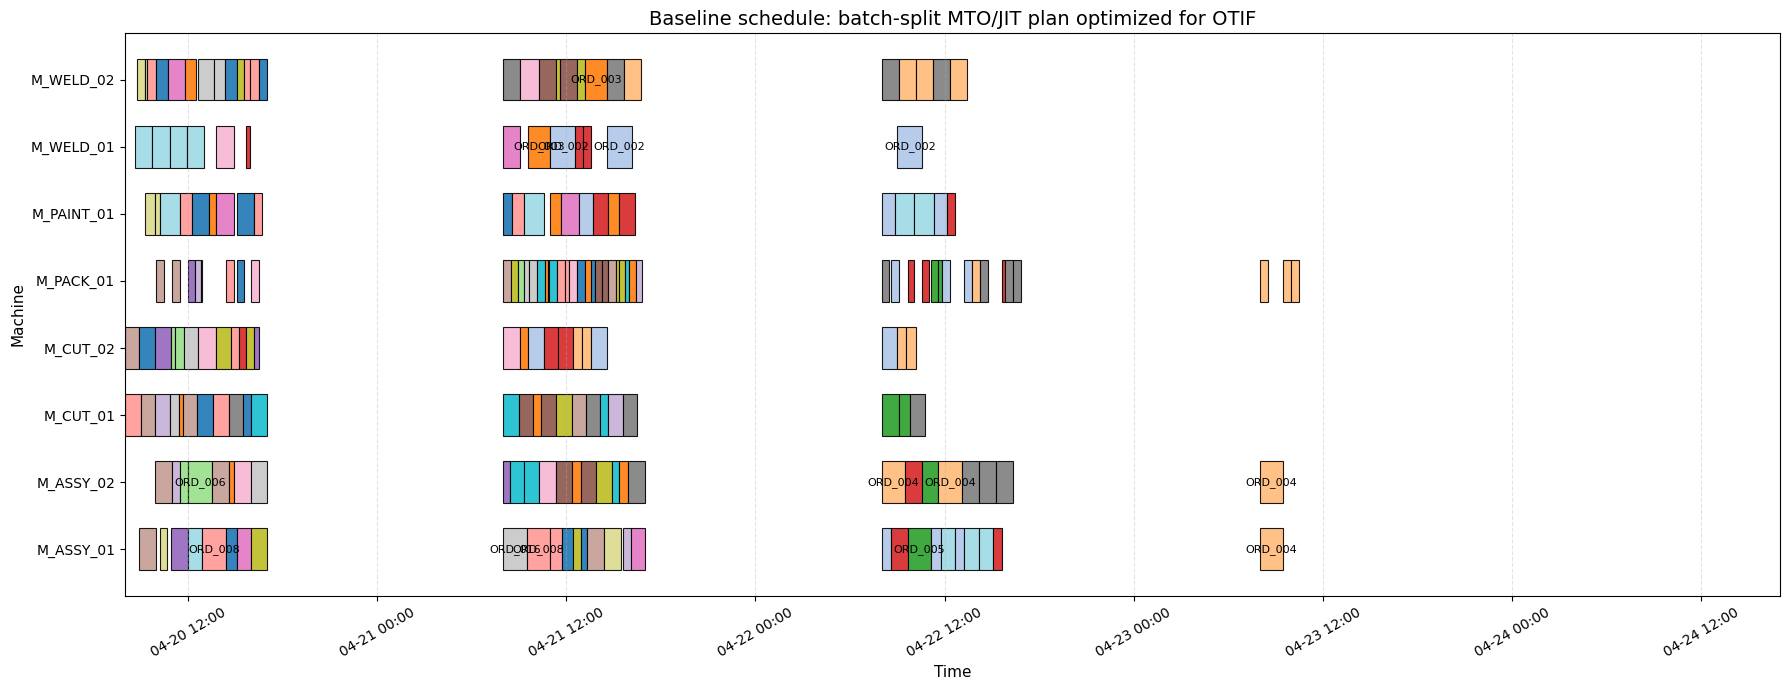

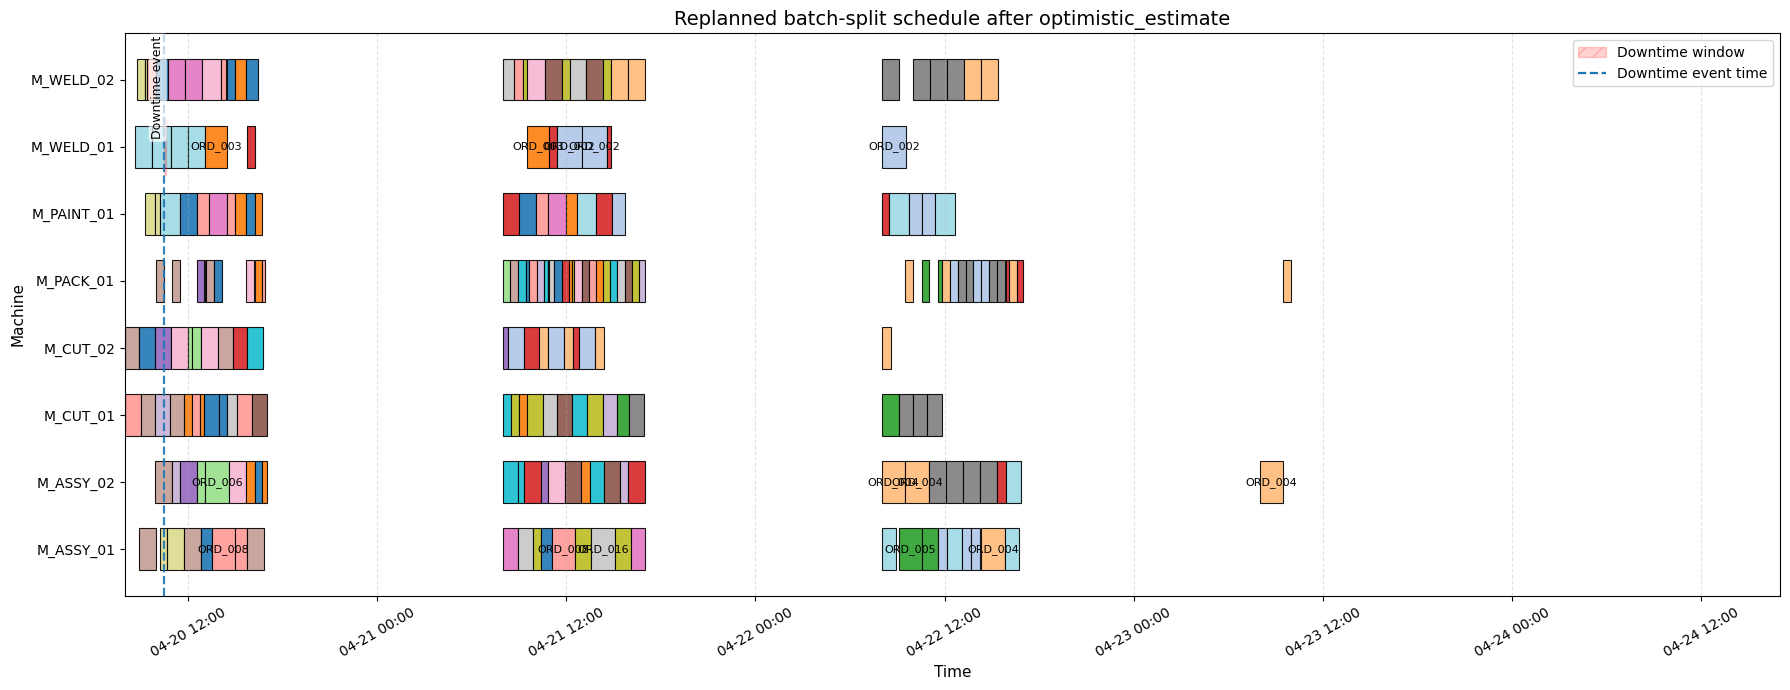

In [12]:
selected_downtime = bundle.downtime_events[
    bundle.downtime_events["scenario_name"] == scenario_name
].copy()

machine_order = sorted(
    set(baseline.schedule["machine_id"].dropna().astype(str))
    | set(replanned.schedule["machine_id"].dropna().astype(str))
)

plot_gantt_v2(
    baseline.schedule,
    "Baseline schedule: batch-split MTO/JIT plan optimized for OTIF",
    shifts_df=bundle.shifts,
    machine_order=machine_order,
    label_mode="order",
    min_label_minutes=85,
    xlim_mode="shift_span",
)

plot_gantt_v2(
    replanned.schedule,
    f"Replanned batch-split schedule after {scenario_name}",
    downtime_df=selected_downtime,
    shifts_df=bundle.shifts,
    event_time=replanned.metadata.get("replan_time"),
    machine_order=machine_order,
    downtime_duration_col="estimated_duration_minutes",
    label_mode="order",
    min_label_minutes=85,
    xlim_mode="shift_span",
)


## 6. Export results


In [13]:
baseline.schedule.to_csv(OUTPUT_DIR / "baseline_schedule.csv", index=False)
baseline.order_summary.to_csv(OUTPUT_DIR / "baseline_order_summary.csv", index=False)
replanned.schedule.to_csv(OUTPUT_DIR / f"{scenario_name}_schedule.csv", index=False)
replanned.order_summary.to_csv(OUTPUT_DIR / f"{scenario_name}_order_summary.csv", index=False)
kpi_comparison.to_csv(OUTPUT_DIR / f"{scenario_name}_kpi_comparison.csv")
order_compare.to_csv(OUTPUT_DIR / f"{scenario_name}_order_otif_comparison.csv", index=False)

print(f"Saved outputs to: {OUTPUT_DIR.resolve()}")


Saved outputs to: /datasets/_deepnote_work/test_optimal_planning/scheduler_outputs


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=a0401ead-6d52-4f6a-b46e-cd13069c77d8' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>